# Pitcher Wins ANN Experiment

This notebook is a cleaned-up version of `Testing-ANN.py`. It keeps the original idea of predicting pitcher wins from rate stats, but makes a few practical upgrades:

- uses the package API instead of the old `newstatscraping` import
- treats wins as a regression target instead of hard-coded classes
- filters and preprocesses the model frame explicitly
- compares the ANN against a simple mean-wins baseline
- reports MAE, RMSE, R2, and the share of predictions within 2 wins
- keeps train, validation, and test sets separate

In [1]:
import copy
import os
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import mlbstatscraping as ss

# Helpful on some local macOS/PyTorch installs that hit duplicate OpenMP warnings.
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

pd.set_option("display.max_columns", 100)

## Configuration

In [2]:
YEAR = 2022
TBF_LIMIT = 100

FEATURE_COLUMNS = [
    "ER_per_TBF",
    "SO_per_TBF",
    "BB_per_TBF",
    "HR_per_TBF",
    "H_per_TBF",
]
TARGET_COLUMN = "W"

## Load Fangraphs Pitching Data

In [3]:
pitching = ss.get_fangraphs_data("pitching", [str(YEAR)])
pitching.head()

,season,Name,Team,Age,W,L,ERA,G,GS,QS,CG,ShO,SV,HLD,BS,IP,TBF,H,R,ER,HR,BB,IBB,HBP,WP,BK,SO,Year
0,2022,Sandy Alcantara,MIA,26.0,14.0,9.0,2.282799,32.0,32.0,24.0,6.0,1.0,0.0,0.0,0.0,228.2,886.0,174.0,67.0,58.0,16.0,50.0,1.0,9.0,3.0,0.0,207.0,2022
1,2022,Aaron Nola,PHI,29.0,11.0,13.0,3.248781,32.0,32.0,18.0,2.0,1.0,0.0,0.0,0.0,205.0,807.0,168.0,75.0,74.0,19.0,29.0,1.0,9.0,2.0,0.0,235.0,2022
2,2022,Miles Mikolas,STL,33.0,12.0,13.0,3.291598,33.0,32.0,22.0,1.0,0.0,0.0,0.0,0.0,202.1,805.0,170.0,81.0,74.0,25.0,39.0,0.0,6.0,1.0,1.0,153.0,2022
3,2022,Corbin Burnes,MIL,27.0,12.0,8.0,2.940594,33.0,33.0,21.0,0.0,0.0,0.0,0.0,0.0,202.0,797.0,144.0,73.0,66.0,23.0,51.0,0.0,13.0,10.0,0.0,243.0,2022
4,2022,Framber Valdez,HOU,28.0,17.0,6.0,2.816225,31.0,31.0,26.0,3.0,1.0,0.0,0.0,0.0,201.1,827.0,166.0,71.0,63.0,11.0,67.0,0.0,11.0,11.0,1.0,194.0,2022


## Build a Model Frame

The original script normalized several counting stats by batters faced. That is a good instinct: a pitcher with more innings naturally collects more wins and more events, so rates are a cleaner way to ask whether the underlying profile predicts wins.

In [4]:
def build_pitching_model_frame(df, tbf_limit=100):
    frame = df.copy()
    numeric_columns = ["TBF", "HR", "H", "BB", "ER", "SO", "W"]

    for column in numeric_columns:
        frame[column] = pd.to_numeric(frame[column], errors="coerce")

    frame = frame.loc[frame["TBF"] > tbf_limit].copy()
    frame["HR_per_TBF"] = frame["HR"] / frame["TBF"]
    frame["H_per_TBF"] = frame["H"] / frame["TBF"]
    frame["BB_per_TBF"] = frame["BB"] / frame["TBF"]
    frame["ER_per_TBF"] = frame["ER"] / frame["TBF"]
    frame["SO_per_TBF"] = frame["SO"] / frame["TBF"]

    model_columns = ["Name", "Team", "Year", TARGET_COLUMN, *FEATURE_COLUMNS]
    frame = frame.replace([np.inf, -np.inf], np.nan)
    return frame[model_columns].dropna().reset_index(drop=True)


model_df = build_pitching_model_frame(pitching, TBF_LIMIT)
print(f"Rows after TBF>{TBF_LIMIT}: {len(model_df)}")
model_df.head()

Rows after TBF>100: 518


,Name,Team,Year,W,ER_per_TBF,SO_per_TBF,BB_per_TBF,HR_per_TBF,H_per_TBF
0,Sandy Alcantara,MIA,2022,14.0,0.065463,0.233634,0.056433,0.018059,0.196388
1,Aaron Nola,PHI,2022,11.0,0.091698,0.291202,0.035936,0.023544,0.208178
2,Miles Mikolas,STL,2022,12.0,0.091925,0.190062,0.048447,0.031056,0.211180
3,Corbin Burnes,MIL,2022,12.0,0.082811,0.304893,0.063990,0.028858,0.180678
4,Framber Valdez,HOU,2022,17.0,0.076179,0.234583,0.081016,0.013301,0.200726


In [5]:
model_df[[TARGET_COLUMN, *FEATURE_COLUMNS]].describe().T

,count,mean,std,min,25%,50%,75%,max
W,518.0,4.465251,3.747565,0.000000,2.000000,4.000000,6.000000,21.000000
ER_per_TBF,518.0,0.104049,0.030923,0.028571,0.083028,0.101629,0.125000,0.244755
SO_per_TBF,518.0,0.227321,0.057138,0.106195,0.187823,0.223140,0.261830,0.502128
BB_per_TBF,518.0,0.085763,0.027911,0.022222,0.064804,0.084078,0.102454,0.180952
HR_per_TBF,518.0,0.027954,0.013064,0.000000,0.019418,0.027112,0.034981,0.083916
H_per_TBF,518.0,0.215140,0.036000,0.109804,0.191287,0.213538,0.241286,0.333333


## Split and Scale

The scaler is fit only on the training set. Validation and test data are transformed with that same scaler.

In [6]:
train_df, test_df = train_test_split(
    model_df,
    test_size=0.20,
    random_state=RANDOM_STATE,
)
train_df, val_df = train_test_split(
    train_df,
    test_size=0.20,
    random_state=RANDOM_STATE,
)

scaler = StandardScaler()
X_train = scaler.fit_transform(train_df[FEATURE_COLUMNS]).astype(np.float32)
X_val = scaler.transform(val_df[FEATURE_COLUMNS]).astype(np.float32)
X_test = scaler.transform(test_df[FEATURE_COLUMNS]).astype(np.float32)

y_train = train_df[TARGET_COLUMN].to_numpy(dtype=np.float32).reshape(-1, 1)
y_val = val_df[TARGET_COLUMN].to_numpy(dtype=np.float32).reshape(-1, 1)
y_test = test_df[TARGET_COLUMN].to_numpy(dtype=np.float32).reshape(-1, 1)

print(X_train.shape, X_val.shape, X_test.shape)

(331, 5) (83, 5) (104, 5)


## Baseline Metrics

A mean-wins predictor is not clever, but it is a useful sanity check. The ANN should beat this before we trust it for anything interesting.

In [7]:
def evaluate_predictions(y_true, y_pred):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred, squared=False),
        "R2": r2_score(y_true, y_pred),
        "Within 2 Wins": np.mean(np.abs(y_true - y_pred) <= 2),
    }


baseline_pred = np.full_like(y_test, y_train.mean())
pd.Series(evaluate_predictions(y_test, baseline_pred), name="Mean baseline")

MAE              3.010661
RMSE             4.011688
R2              -0.004744
Within 2 Wins    0.432692
Name: Mean baseline, dtype: float64

## Train a Small ANN Regressor

In [8]:
class WinsANN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.10),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
        )

    def forward(self, x):
        return self.net(x)


X_train_t = torch.tensor(X_train)
X_val_t = torch.tensor(X_val)
X_test_t = torch.tensor(X_test)
y_train_t = torch.tensor(y_train)
y_val_t = torch.tensor(y_val)

model = WinsANN(input_dim=X_train.shape[1])
criterion = nn.SmoothL1Loss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.01, weight_decay=0.001)

In [9]:
EPOCHS = 500
PATIENCE = 40
best_val_loss = float("inf")
best_state = None
epochs_without_improvement = 0
history = []

for epoch in range(EPOCHS):
    model.train()
    optimizer.zero_grad()
    train_pred = model(X_train_t)
    train_loss = criterion(train_pred, y_train_t)
    train_loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        val_loss = criterion(model(X_val_t), y_val_t)

    history.append(
        {
            "epoch": epoch,
            "train_loss": train_loss.item(),
            "val_loss": val_loss.item(),
        }
    )

    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        best_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= PATIENCE:
        print(f"Early stopping at epoch {epoch}")
        break

model.load_state_dict(best_state)
history_df = pd.DataFrame(history)
history_df.tail()

Early stopping at epoch 222


,epoch,train_loss,val_loss
218,218,1.771032,1.977730
219,219,1.772794,1.981827
220,220,1.815204,1.989094
221,221,1.764243,2.010566
222,222,1.764562,2.036610


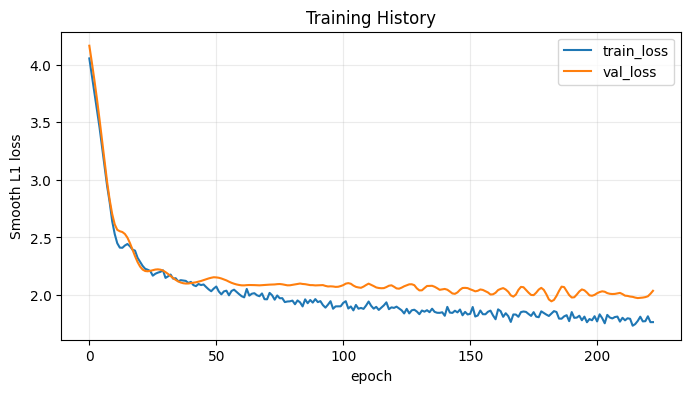

In [10]:
ax = history_df.plot(x="epoch", y=["train_loss", "val_loss"], figsize=(8, 4))
ax.set_title("Training History")
ax.set_ylabel("Smooth L1 loss")
ax.grid(alpha=0.25)

## Test Set Evaluation

In [11]:
model.eval()
with torch.no_grad():
    ann_pred = model(X_test_t).numpy().ravel()

# Wins cannot be negative, so clip the final predictions at zero.
ann_pred = np.clip(ann_pred, 0, None)

metrics = pd.DataFrame(
    {
        "Mean baseline": evaluate_predictions(y_test, baseline_pred),
        "ANN": evaluate_predictions(y_test, ann_pred),
    }
).T
metrics

,MAE,RMSE,R2,Within 2 Wins
Mean baseline,3.010661,4.011688,-0.004744,0.432692
ANN,2.552085,3.458796,0.253120,0.500000


In [12]:
predictions = test_df[["Name", "Team", "Year", TARGET_COLUMN, *FEATURE_COLUMNS]].copy()
predictions["Predicted_W"] = ann_pred
predictions["Error"] = predictions["Predicted_W"] - predictions[TARGET_COLUMN]
predictions["Abs_Error"] = predictions["Error"].abs()

predictions.sort_values("Abs_Error", ascending=False).head(10)

,Name,Team,Year,W,ER_per_TBF,SO_per_TBF,BB_per_TBF,HR_per_TBF,H_per_TBF,Predicted_W,Error,Abs_Error
33,Justin Verlander,HOU,2022,18.0,0.051051,0.277778,0.043544,0.018018,0.174174,5.969443,-12.030557,12.030557
10,Yu Darvish,SDP,2022,16.0,0.086900,0.255512,0.047990,0.028534,0.191958,5.722044,-10.277956,10.277956
18,Dylan Cease,CHW,2022,14.0,0.060241,0.303882,0.104418,0.021419,0.168675,4.343408,-9.656592,9.656592
11,Logan Webb,SFG,2022,15.0,0.078780,0.207116,0.062262,0.013977,0.221093,5.799072,-9.200928,9.200928
6,Merrill Kelly,ARI,2022,13.0,0.093284,0.220149,0.075871,0.026119,0.207711,5.581503,-7.418497,7.418497
0,Sandy Alcantara,MIA,2022,14.0,0.065463,0.233634,0.056433,0.018059,0.196388,6.581553,-7.418447,7.418447
55,Brandon Woodruff,MIL,2022,13.0,0.083871,0.306452,0.067742,0.029032,0.196774,5.643098,-7.356902,7.356902
9,Martin Perez,TEX,2022,12.0,0.076736,0.205847,0.084044,0.013398,0.216809,5.045837,-6.954163,6.954163
2,Miles Mikolas,STL,2022,12.0,0.091925,0.190062,0.048447,0.031056,0.211180,5.929706,-6.070294,6.070294
63,Cristian Javier,HOU,2022,11.0,0.071795,0.331624,0.088889,0.029060,0.152137,4.980512,-6.019488,6.019488


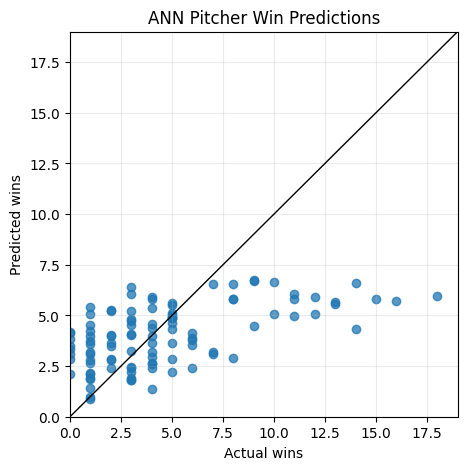

In [13]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(predictions[TARGET_COLUMN], predictions["Predicted_W"], alpha=0.75)
lims = [0, max(predictions[TARGET_COLUMN].max(), predictions["Predicted_W"].max()) + 1]
ax.plot(lims, lims, color="black", linewidth=1)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("Actual wins")
ax.set_ylabel("Predicted wins")
ax.set_title("ANN Pitcher Win Predictions")
ax.grid(alpha=0.25)

## Easy Next Experiments

- Try several years at once, for example `YEARS = ["2021", "2022", "2023", "2024"]`.
- Use `advanced=True` in `get_fangraphs_data` and add defense-independent stats as features.
- Predict next-year wins by joining one season's features to the following season's target.
- Compare the ANN with a simple linear model. With a small dataset, linear often wins.